In [24]:
import numpy as np
import yfinance as yf
import time
from datetime import datetime
from typing import Dict, Optional, Callable

In [ ]:
"""
On va checker la documentation de yfinance, voir si on peut bien se connecter au websocket avant cela je vais verifier qu'on peut récuperer les datas qu'on a besoin pour le projet. 

Par défault de websocket accessible avec les données qu'il nous interésse on passe en REST API quasi live en utilisant un polling fréquent avec FRED, ECB, treasury.gov

On va essayer de configurer celle-ci, dans le cas ou le live ne marche pas on re-basculera sur yfinance, on risque de trouver des écarts d'un run à l'autre donc on pourrait sauvegarder les datas en pkq.
"""
from settings import get_logger
import os
from dotenv import load_dotenv
import requests
from fredapi import Fred
import pandas as pd

load_dotenv()

FRED_API_KEY = os.getenv("fred_api_key")


In [ ]:
logger = get_logger(name='jupyter_api')
fred = Fred(api_key=FRED_API_KEY)

In [36]:
if not FRED_API_KEY:
    print("Erreur : FRED API key non trouvée dans l'environnement.")
else:
    url = "https://api.stlouisfed.org/fred/series/search"
    params = {
        "api_key": FRED_API_KEY,
        "search_text": "canada",
        "file_type": "json"
    }
    try:
        response = requests.get(url, params=params, timeout=10)
        response.raise_for_status()  # Lève une exception pour les erreurs 4xx/5xx
        data = response.json()
        print("Connecté sur l'api")
        # On affiche les séries disponibles plutôt que tout le JSON car volumineux
        series = data.get('seriess', [])
        if not series:
            print("Aucune série pour ce criteres")
        else:
            for s in series[:3]:  # Affiche les 3 premières séries trouvées
                print(f"- ID: {s['id']} | Title: {s['title']}")
    except requests.exceptions.RequestException as e:
        print("Erreur lors de la connexion à l'API FRED:", e)
    except Exception as e:
        print("Erreur inattendue lors du traitement de la réponse FRED:", e)


Connecté sur l'api
- ID: QCAR628BIS | Title: Real Residential Property Prices for Canada
- ID: QCAR368BIS | Title: Real Residential Property Prices for Canada
- ID: NGDPRSAXDCCAQ | Title: Real Gross Domestic Product for Canada


In [54]:
#https://github.com/DanTCIM/TreasuryYieldTracker/blob/main/code/TreasuryYieldTracker.ipynb

# manque 6 maturités — 6M, 1Y, 2Y, 3Y, 7Y, 20Y
# yfinance ne couvre que 3M/5Y/10Y/30Y

series_ids = {
    "6-Month": "DGS6MO",
    "1-Year": "DGS1",
    "2-Year": "DGS2",
    "3-Year": "DGS3",
    "7-Year": "DGS7",
    "20-Year": "DGS20"
}

# Download each series and merge into one DataFrame
df_list = []
for label, code in series_ids.items():
    series = fred.get_series(code)
    df = series.rename(label).to_frame()
    df_list.append(df)

# Merge on index (i.e., Date)
combined_df = pd.concat(df_list, axis=1)
combined_df.index.name = "Date"
combined_df = combined_df.dropna(how="all")


In [55]:
# Reset index to make 'Date' a column
combined_df = combined_df.reset_index()

In [56]:
print(combined_df.tail())  # For Jupyter or console
print(combined_df.head())  # For Jupyter or console


            Date  6-Month  1-Year  2-Year  3-Year  7-Year  20-Year
16040 2026-03-25     3.76    3.77    3.84    3.88    4.15     4.90
16041 2026-03-26     3.77    3.83    3.96    4.00    4.25     4.96
16042 2026-03-27     3.75    3.77    3.88    3.94    4.25     4.99
16043 2026-03-30     3.73    3.71    3.82    3.85    4.16     4.92
16044 2026-03-31     3.72    3.68    3.79    3.81    4.11     4.88
        Date  6-Month  1-Year  2-Year  3-Year  7-Year  20-Year
0 1962-01-02      NaN    3.22     NaN    3.70     NaN     4.07
1 1962-01-03      NaN    3.24     NaN    3.70     NaN     4.07
2 1962-01-04      NaN    3.24     NaN    3.69     NaN     4.06
3 1962-01-05      NaN    3.26     NaN    3.71     NaN     4.07
4 1962-01-08      NaN    3.31     NaN    3.71     NaN     4.08


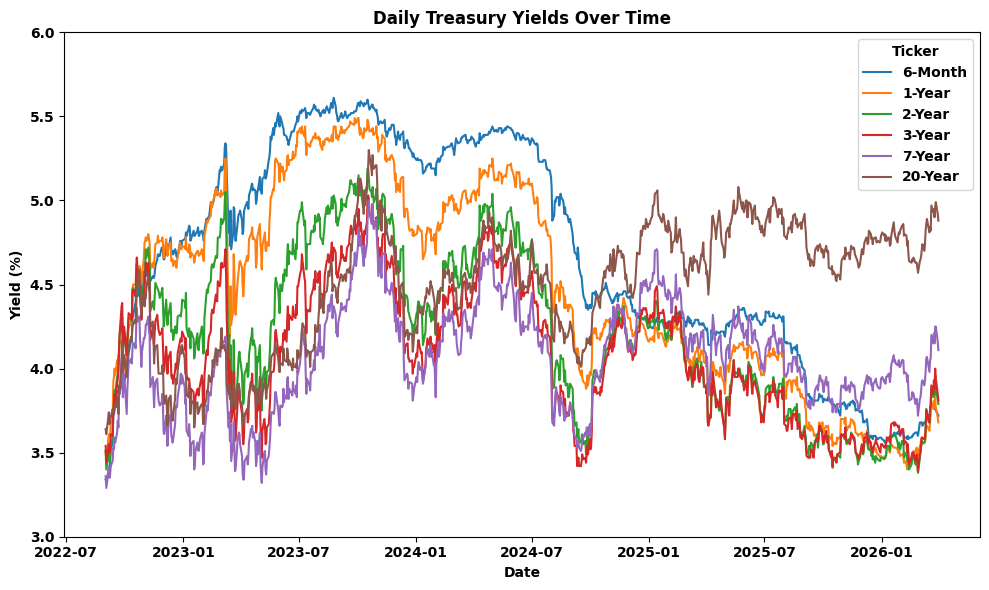

In [60]:
import altair as alt

# Melt for long format
melted_df = combined_df.melt(id_vars='Date', var_name='Ticker', value_name='Yield')

# Filter data to only keep records from September 2022 onwards
melted_df = melted_df[melted_df['Date'] >= '2022-09-01']

# Remove NaN yields (some maturities are missing on certain dates)
melted_df.dropna(subset=["Yield"], inplace=True)

# Calculate y-axis bounds
min_y_value = melted_df['Yield'].min()
max_y_value = melted_df['Yield'].max()
y_start = np.floor(min_y_value * 2) / 2
y_end = np.ceil(max_y_value * 2) / 2

# Sorting list for legend and line color order
output_list = list(series_ids.keys())

import matplotlib.pyplot as plt

# Group data by ticker for plotting each as a line
fig, ax = plt.subplots(figsize=(10, 6))

for ticker in output_list:  # Preserve order
    ticker_df = melted_df[melted_df['Ticker'] == ticker]
    ax.plot(
        ticker_df['Date'],
        ticker_df['Yield'],
        label=ticker
    )

ax.set_xlabel('Date')
ax.set_ylabel('Yield (%)')
ax.set_title('Daily Treasury Yields Over Time')
ax.set_ylim([y_start, y_end])
ax.legend(title='Ticker')
plt.tight_layout()
plt.show()
